# AWS Cost Audit — Cost Analysis

## Audit Objective

This notebook analyzes validated AWS Cost Explorer data for the
audit period of June 1, 2026 through August 31, 2026.

The objective is to:

- Understand total AWS spending.
- Identify the highest-cost AWS services.
- Analyze monthly spending trends.
- Measure month-over-month cost changes.
- Identify unusual cost increases and potential areas for investigation.
- Produce evidence that can support later audit findings and recommendations.

> Important: High cost does not automatically mean waste.
> This analysis identifies areas requiring investigation. Waste will
> only be concluded after additional evidence is reviewed.

## 1. Import Required Libraries

We begin by importing the Python libraries required for the analysis.

- `pandas` is used for data loading, transformation, and analysis.
- `matplotlib` is used for visualizing cost trends.
- `pathlib` is used to locate the processed audit dataset.

No AWS data is modified during this analysis stage.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

## 2. Locate the Processed Dataset

The validated CSV generated by the ETL pipeline is stored in:

`data/processed/`

This notebook will use the processed dataset rather than the raw JSON.

The raw JSON in `data/raw/` remains unchanged and serves as the original
source data for the audit.

In [2]:
project_root = Path.cwd().parent
processed_directory = project_root / "data" / "processed"

csv_files = list(processed_directory.glob("*.csv"))

csv_files

[WindowsPath('c:/Users/Crystal Brook/downloads/IZU-AWS-AUDIT-PREP-PYTHON/data/processed/clean_cost_data_2026-09-09_12-25-17.csv')]

## 3. Select the Audit Dataset

We identify the processed CSV file that will be used for this analysis.

The selected file represents the cleaned and validated data produced
by the ETL pipeline.

In [3]:
if not csv_files:
    raise FileNotFoundError(
        "No processed CSV files were found in data/processed."
    )

csv_file = max(
    csv_files,
    key=lambda file: file.stat().st_mtime
)

csv_file

WindowsPath('c:/Users/Crystal Brook/downloads/IZU-AWS-AUDIT-PREP-PYTHON/data/processed/clean_cost_data_2026-09-09_12-25-17.csv')

## 4. Load the Processed Dataset

The selected CSV file is loaded into a pandas DataFrame.

At this stage, we are not modifying the data. The purpose is to bring
the validated dataset into the notebook so that we can begin auditing
AWS spending.

In [4]:
df = pd.read_csv(csv_file)

df.head()

,start_date,end_date,service,cost,currency,estimated
0,2026-06-01,2026-07-01,AWS CloudShell,8.780000e-08,USD,False
1,2026-06-01,2026-07-01,AWS Glue,0.000000e+00,USD,False
2,2026-06-01,2026-07-01,AWS Key Management Service,9.166667e-02,USD,False
3,2026-06-01,2026-07-01,AWS Lambda,0.000000e+00,USD,False
4,2026-06-01,2026-07-01,AWS Secrets Manager,1.759670e-03,USD,False


## 5. Inspect Dataset Dimensions

We inspect the number of rows and columns in the dataset.

The number of rows represents the number of service-level cost records
available for analysis.

In [5]:
df.shape

(41, 6)

## 6. Inspect Dataset Columns

We inspect the column names to confirm that the processed dataset
contains the fields required for cost analysis.

Expected fields include:

- `start_date`
- `end_date`
- `service`
- `cost`
- `currency`
- `estimated`

In [6]:
df.columns.tolist()

['start_date', 'end_date', 'service', 'cost', 'currency', 'estimated']

## 7. Inspect Data Types

We check the data types of each column.

This is important for auditing because calculations such as cost totals,
percentage changes, and date comparisons require the underlying values
to have the correct data types.

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41 entries, 0 to 40
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   start_date  41 non-null     str    
 1   end_date    41 non-null     str    
 2   service     41 non-null     str    
 3   cost        41 non-null     float64
 4   currency    41 non-null     str    
 5   estimated   41 non-null     bool   
dtypes: bool(1), float64(1), str(4)
memory usage: 1.8 KB


## 8. Review the Complete Dataset

We display the processed dataset to understand the actual AWS services
and cost records returned by Cost Explorer.

This provides an initial view of the data before performing financial
analysis.

In [8]:
df

,start_date,end_date,service,cost,currency,estimated
0,2026-06-01,2026-07-01,AWS CloudShell,8.780000e-08,USD,False
1,2026-06-01,2026-07-01,AWS Glue,0.000000e+00,USD,False
2,2026-06-01,2026-07-01,AWS Key Management Service,9.166667e-02,USD,False
3,2026-06-01,2026-07-01,AWS Lambda,0.000000e+00,USD,False
4,2026-06-01,2026-07-01,AWS Secrets Manager,1.759670e-03,USD,False
5,2026-06-01,2026-07-01,Amazon Elastic Compute Cloud - Compute,2.031030e+00,USD,False
6,2026-06-01,2026-07-01,Amazon Simple Notification Service,0.000000e+00,USD,False
7,2026-06-01,2026-07-01,Amazon Simple Queue Service,0.000000e+00,USD,False
8,2026-06-01,2026-07-01,Amazon Simple Storage Service,2.680939e-03,USD,False
9,2026-06-01,2026-07-01,Amazon Virtual Private Cloud,7.668000e-01,USD,False


## 9. Check for Missing Values

Missing values can affect financial calculations and potentially lead
to incorrect audit conclusions.

We therefore verify whether any required fields contain missing values.

The transformation stage already performed validation, but the notebook
performs an additional check before analysis.

In [9]:
df.isnull().sum()

start_date    0
end_date      0
service       0
cost          0
currency      0
estimated     0
dtype: int64

## 10. Check for Duplicate Records

Duplicate cost records could cause AWS spending to be counted more than
once.

We check for duplicates before calculating totals or rankings.

In [10]:
df.duplicated().sum()

np.int64(0)

## 11. Verify the Audit Period

The requested audit period is:

**June 1, 2026 → August 31, 2026**

Because Cost Explorer uses an exclusive end date, the August monthly
record ends on September 1, 2026.

We verify that the processed dataset contains the expected audit period.

In [11]:
df[["start_date", "end_date"]].drop_duplicates()

,start_date,end_date
0,2026-06-01,2026-07-01
13,2026-07-01,2026-08-01
25,2026-08-01,2026-09-01


## 12. Identify AWS Services

We identify all AWS services represented in the dataset.

This is the first step toward determining which services are responsible
for the client's AWS spending.

In [12]:
df["service"].unique()

<StringArray>
[                        'AWS CloudShell',
                               'AWS Glue',
             'AWS Key Management Service',
                             'AWS Lambda',
                    'AWS Secrets Manager',
 'Amazon Elastic Compute Cloud - Compute',
     'Amazon Simple Notification Service',
            'Amazon Simple Queue Service',
          'Amazon Simple Storage Service',
           'Amazon Virtual Private Cloud',
                       'AmazonCloudWatch',
                            'EC2 - Other',
                                    'Tax',
          'Amazon Elastic Load Balancing',
                'AWS Certificate Manager',
                        'Amazon DynamoDB',
             'Amazon Elastic File System',
                        'Amazon Route 53']
Length: 18, dtype: str

## 13. Count Records by AWS Service

We count the number of records associated with each AWS service.

This helps us understand the structure of the dataset before calculating
service-level spending.

In [13]:
df["service"].value_counts()

service
AWS Glue                                  3
AWS Key Management Service                3
AWS Secrets Manager                       3
Amazon Elastic Compute Cloud - Compute    3
Amazon Simple Notification Service        3
Amazon Simple Queue Service               3
Amazon Simple Storage Service             3
Amazon Virtual Private Cloud              3
AmazonCloudWatch                          3
EC2 - Other                               3
Tax                                       3
Amazon Elastic Load Balancing             2
AWS CloudShell                            1
AWS Lambda                                1
AWS Certificate Manager                   1
Amazon DynamoDB                           1
Amazon Elastic File System                1
Amazon Route 53                           1
Name: count, dtype: int64

## 14. Calculate Total AWS Spend

The first financial metric is the total AWS spend across the entire
audit period.

This establishes the overall financial baseline for the audit before
we break the spending down by month or AWS service.

In [14]:
total_spend = df["cost"].sum()

total_spend

np.float64(27.6558956484)

### Total AWS Spend

The value below represents the total recorded AWS spend across all
services during the audit period.

In [15]:
print(f"Total AWS spend: ${total_spend:,.2f}")

Total AWS spend: $27.66


## 15. Calculate Monthly AWS Spend

We now break the total AWS spending down by month.

This allows us to understand how spending changed throughout the
audit period and provides the baseline for month-over-month analysis.

In [16]:
monthly_spend = (
    df.groupby("start_date", as_index=False)["cost"]
    .sum()
)

monthly_spend

,start_date,cost
0,2026-06-01,4.439400
1,2026-07-01,9.376213
2,2026-08-01,13.840283


## 15.1 Convert Dates to Datetime

The processed CSV stores dates as text when it is written to disk.
Before performing time-based analysis or using pandas datetime
operations, the date column must be explicitly converted to a
datetime data type.

This ensures that monthly sorting, date calculations, and time-series
visualizations work correctly.

In [17]:
df["start_date"] = pd.to_datetime(
    df["start_date"],
    errors="coerce"
)

df["end_date"] = pd.to_datetime(
    df["end_date"],
    errors="coerce"
)

In [18]:
df[["start_date", "end_date"]].dtypes

start_date    datetime64[us]
end_date      datetime64[us]
dtype: object

## 16. Review Monthly Spending

The monthly spending results are formatted to two decimal places to
make the financial figures easier to interpret.

In [19]:
monthly_spend = (
    df.groupby("start_date", as_index=False)["cost"]
    .sum()
)

monthly_spend["cost"] = monthly_spend["cost"].round(2)

monthly_spend

,start_date,cost
0,2026-06-01,4.44
1,2026-07-01,9.38
2,2026-08-01,13.84


## 17. Identify the Highest-Spend Month

Identifying the highest-spend month helps determine when AWS spending
reached its peak during the audit period.

A high-spend month is not automatically evidence of waste. It is a
starting point for further investigation.

In [20]:
highest_spend_month = monthly_spend.loc[
    monthly_spend["cost"].idxmax()
]

highest_spend_month

start_date    2026-08-01 00:00:00
cost                        13.84
Name: 2, dtype: object

In [21]:
print(
    f"Highest-spend month: "
    f"{highest_spend_month['start_date'].strftime('%B %Y')} "
    f"(${highest_spend_month['cost']:,.2f})"
)

Highest-spend month: August 2026 ($13.84)


## 18. Identify the Lowest-Spend Month

We identify the month with the lowest AWS spending to establish the
lower end of the spending range during the audit period.

In [22]:
lowest_spend_month = monthly_spend.loc[
    monthly_spend["cost"].idxmin()
]

print(
    f"Lowest-spend month: "
    f"{lowest_spend_month['start_date'].strftime('%B %Y')} "
    f"(${lowest_spend_month['cost']:,.2f})"
)

Lowest-spend month: June 2026 ($4.44)


## 19. Calculate Average Monthly Spend

The average monthly spend provides a baseline against which individual
months can be compared.

This metric helps identify months where spending was substantially
above or below the normal level observed during the audit period.

In [23]:
average_monthly_spend = monthly_spend["cost"].mean()

print(f"Average monthly AWS spend: ${average_monthly_spend:,.2f}")

Average monthly AWS spend: $9.22


## 20. Visualize Monthly AWS Spending

A line chart is used to visualize the monthly AWS spending trend.

The purpose of this visualization is to make increases or decreases
in spending easier to identify.

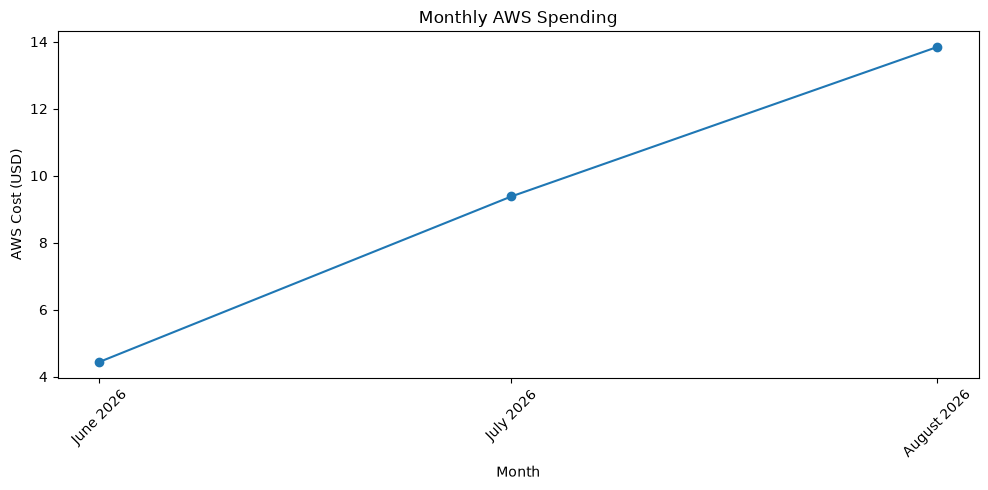

In [24]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_spend["start_date"],
    monthly_spend["cost"],
    marker="o"
)

plt.title("Monthly AWS Spending")
plt.xlabel("Month")
plt.ylabel("AWS Cost (USD)")

plt.xticks(
    monthly_spend["start_date"],
    monthly_spend["start_date"].dt.strftime("%B %Y"),
    rotation=45
)

plt.tight_layout()
plt.show()

## 19.1 Total Cost by AWS Service

The first step of service-level analysis is to calculate the total cost
associated with each AWS service across the entire audit period.

This allows us to rank services from the highest cost to the lowest cost
and identify the primary cost drivers that require further investigation.

In [25]:
service_spend = (
    df.groupby("service", as_index=False)["cost"]
    .sum()
    .sort_values("cost", ascending=False)
)

service_spend["cost"] = service_spend["cost"].round(2)

service_spend

,service,cost
16,EC2 - Other,8.64
0,AWS Certificate Manager,7.00
14,Amazon Virtual Private Cloud,4.84
7,Amazon Elastic Compute Cloud - Compute,4.82
17,Tax,1.92
9,Amazon Elastic Load Balancing,0.33
3,AWS Key Management Service,0.09
13,Amazon Simple Storage Service,0.01
8,Amazon Elastic File System,0.01
5,AWS Secrets Manager,0.00


## 19.2 Service Share of Total AWS Spend

A service's absolute cost does not show how significant it is relative
to the entire AWS bill.

The percentage of total spend shows the contribution of each service
to the overall AWS cost.

Formula:

Service Share (%) =
Service Cost / Total AWS Cost × 100

In [26]:
total_spend = df["cost"].sum()

service_spend["cost_share_pct"] = (
    service_spend["cost"] / total_spend * 100
).round(2)

service_spend

,service,cost,cost_share_pct
16,EC2 - Other,8.64,31.24
0,AWS Certificate Manager,7.00,25.31
14,Amazon Virtual Private Cloud,4.84,17.50
7,Amazon Elastic Compute Cloud - Compute,4.82,17.43
17,Tax,1.92,6.94
9,Amazon Elastic Load Balancing,0.33,1.19
3,AWS Key Management Service,0.09,0.33
13,Amazon Simple Storage Service,0.01,0.04
8,Amazon Elastic File System,0.01,0.04
5,AWS Secrets Manager,0.00,0.00


## 19.3 Top AWS Cost Drivers

The highest-cost services are the first areas to investigate during
the audit.

High spending does not automatically mean waste. These services are
treated as investigation candidates until additional resource,
configuration, and usage evidence confirms whether optimization is
possible.

In [27]:
top_services = service_spend.head(5)

top_services

,service,cost,cost_share_pct
16,EC2 - Other,8.64,31.24
0,AWS Certificate Manager,7.00,25.31
14,Amazon Virtual Private Cloud,4.84,17.50
7,Amazon Elastic Compute Cloud - Compute,4.82,17.43
17,Tax,1.92,6.94


## 19.4 Top AWS Cost Drivers

A visualization makes it easier to identify which AWS services contribute
the most to the client's overall spending.

The chart will display the highest-cost services in descending order.

This visualization is intended to highlight investigation priorities,
not to determine whether a service is wasteful.

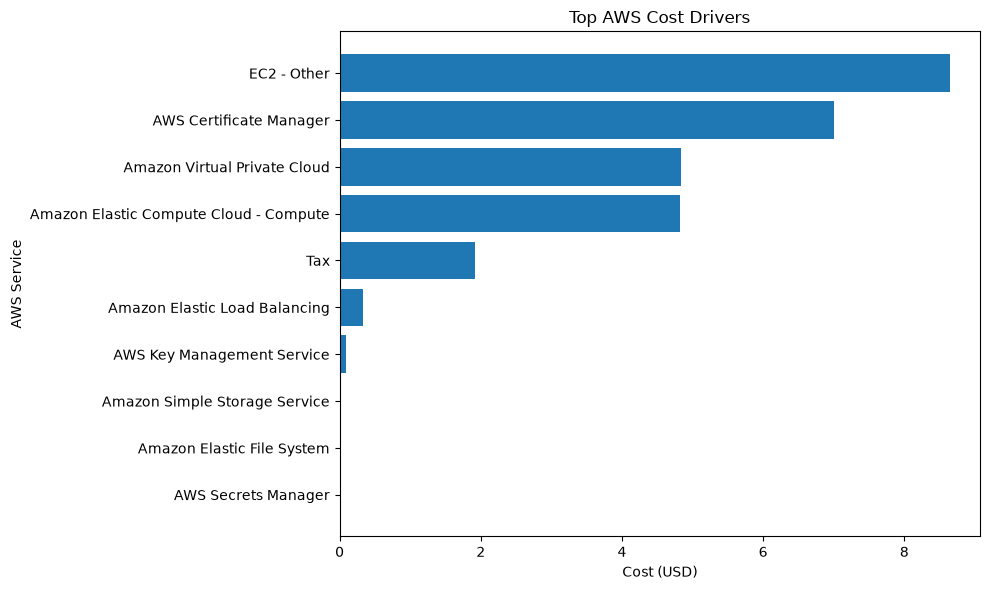

In [28]:
top_services = service_spend.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_services["service"][::-1],
    top_services["cost"][::-1]
)

plt.title("Top AWS Cost Drivers")
plt.xlabel("Cost (USD)")
plt.ylabel("AWS Service")

plt.tight_layout()
plt.show()

## 19.5 Service Cost Distribution

This analysis examines how the total AWS spending is distributed across
services.

Understanding the distribution helps identify whether AWS spending is
concentrated in a small number of services or spread across many services.

A highly concentrated bill allows the audit to prioritize investigation
on the services responsible for most of the spending.

In [29]:
service_distribution = service_spend.copy()

service_distribution

,service,cost,cost_share_pct
16,EC2 - Other,8.64,31.24
0,AWS Certificate Manager,7.00,25.31
14,Amazon Virtual Private Cloud,4.84,17.50
7,Amazon Elastic Compute Cloud - Compute,4.82,17.43
17,Tax,1.92,6.94
9,Amazon Elastic Load Balancing,0.33,1.19
3,AWS Key Management Service,0.09,0.33
13,Amazon Simple Storage Service,0.01,0.04
8,Amazon Elastic File System,0.01,0.04
5,AWS Secrets Manager,0.00,0.00


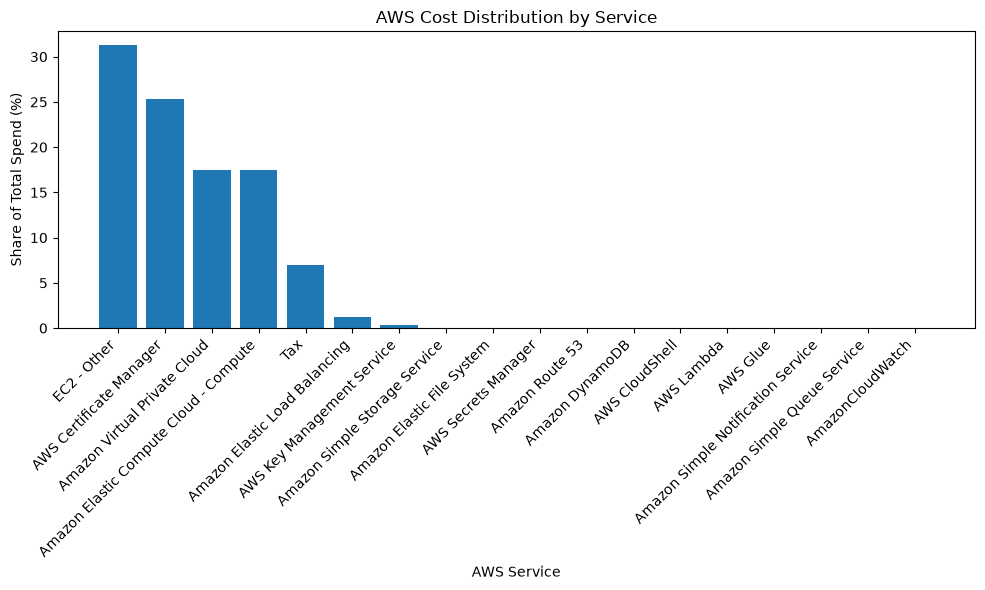

In [30]:
plt.figure(figsize=(10, 6))

plt.bar(
    service_distribution["service"],
    service_distribution["cost_share_pct"]
)

plt.title("AWS Cost Distribution by Service")
plt.xlabel("AWS Service")
plt.ylabel("Share of Total Spend (%)")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

## 19.6 Monthly Service Cost Trends

The previous analysis showed which AWS services contributed the most
to total spending.

This analysis examines how each service's cost changed over the audit
period.

Looking at monthly service trends helps identify:

- Services with increasing costs
- Services with decreasing costs
- Services with stable spending
- Sudden changes that may require investigation

A service with rapidly increasing costs becomes a higher-priority
investigation candidate.

In [31]:
monthly_service_spend = (
    df.groupby(
        ["start_date", "service"],
        as_index=False
    )["cost"]
    .sum()
)

monthly_service_spend["cost"] = (
    monthly_service_spend["cost"].round(2)
)

monthly_service_spend

,start_date,service,cost
0,2026-06-01,AWS CloudShell,0.00
1,2026-06-01,AWS Glue,0.00
2,2026-06-01,AWS Key Management Service,0.09
3,2026-06-01,AWS Lambda,0.00
4,2026-06-01,AWS Secrets Manager,0.00
5,2026-06-01,Amazon Elastic Compute Cloud - Compute,2.03
6,2026-06-01,Amazon Simple Notification Service,0.00
7,2026-06-01,Amazon Simple Queue Service,0.00
8,2026-06-01,Amazon Simple Storage Service,0.00
9,2026-06-01,Amazon Virtual Private Cloud,0.77


## 19.7 Monthly Service Cost Comparison

The monthly service cost table allows us to compare spending for each
AWS service across the audit period.

This provides the foundation for calculating cost changes between
months.

In [32]:
service_trend = monthly_service_spend.pivot(
    index="service",
    columns="start_date",
    values="cost"
).fillna(0)

service_trend

start_date,2026-06-01,2026-07-01,2026-08-01
service,,,
AWS Certificate Manager,0.00,0.00,7.00
AWS CloudShell,0.00,0.00,0.00
AWS Glue,0.00,0.00,0.00
AWS Key Management Service,0.09,0.00,0.00
AWS Lambda,0.00,0.00,0.00
AWS Secrets Manager,0.00,0.00,0.00
Amazon DynamoDB,0.00,0.00,0.00
Amazon Elastic Compute Cloud - Compute,2.03,1.11,1.68
Amazon Elastic File System,0.00,0.00,0.01


## 19.8 Month-over-Month Service Cost Changes

This analysis calculates how much each AWS service's cost changed
between consecutive months.

We examine both:

1. Absolute change in USD
2. Percentage change

Absolute change shows the financial impact of the change, while
percentage change shows how rapidly the service's cost changed.

Both measurements are important because a large percentage increase
does not necessarily represent a large financial impact.

In [33]:
service_mom = service_trend.copy()

# Sort the monthly columns chronologically
service_mom = service_mom.reindex(
    sorted(service_mom.columns),
    axis=1
)

# Calculate month-over-month changes dynamically
for previous_month, current_month in zip(
    service_mom.columns[:-1],
    service_mom.columns[1:]
):
    change_column = (
        f"{previous_month.strftime('%B')}_to_"
        f"{current_month.strftime('%B')}_change"
    )

    service_mom[change_column] = (
        service_mom[current_month] -
        service_mom[previous_month]
    ).round(2)

service_mom

start_date,2026-06-01 00:00:00,2026-07-01 00:00:00,2026-08-01 00:00:00,June_to_July_change,July_to_August_change
service,,,,,
AWS Certificate Manager,0.00,0.00,7.00,0.00,7.00
AWS CloudShell,0.00,0.00,0.00,0.00,0.00
AWS Glue,0.00,0.00,0.00,0.00,0.00
AWS Key Management Service,0.09,0.00,0.00,-0.09,0.00
AWS Lambda,0.00,0.00,0.00,0.00,0.00
AWS Secrets Manager,0.00,0.00,0.00,0.00,0.00
Amazon DynamoDB,0.00,0.00,0.00,0.00,0.00
Amazon Elastic Compute Cloud - Compute,2.03,1.11,1.68,-0.92,0.57
Amazon Elastic File System,0.00,0.00,0.01,0.00,0.01


## 19.9 Month-over-Month Percentage Changes

Absolute dollar changes show the financial impact of a change.

Percentage changes show how significantly a service's spending changed
relative to the previous month.

Both metrics should be considered together during an AWS cost audit.

A very large percentage increase on a low-cost service may have little
financial impact, while a small percentage increase on an expensive
service may represent a significant cost increase.

In [34]:
service_pct_change = service_trend.copy()

# Sort months chronologically
service_pct_change = service_pct_change.reindex(
    sorted(service_pct_change.columns),
    axis=1
)

# Calculate percentage changes
for previous_month, current_month in zip(
    service_pct_change.columns[:-1],
    service_pct_change.columns[1:]
):
    pct_column = (
        f"{previous_month.strftime('%B')}_to_"
        f"{current_month.strftime('%B')}_pct_change"
    )

    previous_cost = service_pct_change[previous_month]
    current_cost = service_pct_change[current_month]

    service_pct_change[pct_column] = (
        (
            (current_cost - previous_cost)
            / previous_cost
        )
        .where(previous_cost != 0)
        .round(2)
    )

service_pct_change

start_date,2026-06-01 00:00:00,2026-07-01 00:00:00,2026-08-01 00:00:00,June_to_July_pct_change,July_to_August_pct_change
service,,,,,
AWS Certificate Manager,0.00,0.00,7.00,NaN,NaN
AWS CloudShell,0.00,0.00,0.00,NaN,NaN
AWS Glue,0.00,0.00,0.00,NaN,NaN
AWS Key Management Service,0.09,0.00,0.00,-1.00,NaN
AWS Lambda,0.00,0.00,0.00,NaN,NaN
AWS Secrets Manager,0.00,0.00,0.00,NaN,NaN
Amazon DynamoDB,0.00,0.00,0.00,NaN,NaN
Amazon Elastic Compute Cloud - Compute,2.03,1.11,1.68,-0.45,0.51
Amazon Elastic File System,0.00,0.00,0.01,NaN,NaN


## 19.10 Largest Month-over-Month Cost Increases

This analysis identifies the AWS services with the largest absolute
increase in spending between consecutive months.

Absolute dollar change is important because percentage growth can be
misleading for low-cost services.

The largest increases will become priority candidates for further
investigation.

In [35]:
# Identify only the month-over-month dollar change columns
change_columns = [
    column
    for column in service_mom.columns
    if isinstance(column, str) and column.endswith("_change")
]

# Find the largest monthly increase for each service
largest_increase = service_mom[change_columns].max(axis=1)

largest_increase_df = pd.DataFrame({
    "service": service_mom.index,
    "largest_monthly_increase": largest_increase
})

largest_increase_df = (
    largest_increase_df
    .sort_values(
        "largest_monthly_increase",
        ascending=False
    )
    .reset_index(drop=True)
)

largest_increase_df["largest_monthly_increase"] = (
    largest_increase_df["largest_monthly_increase"]
    .round(2)
)

largest_increase_df

,service,largest_monthly_increase
0,AWS Certificate Manager,7.00
1,Amazon Virtual Private Cloud,2.88
2,EC2 - Other,2.62
3,Amazon Elastic Compute Cloud - Compute,0.57
4,Tax,0.34
5,Amazon Elastic Load Balancing,0.13
6,Amazon Elastic File System,0.01
7,AWS CloudShell,0.00
8,AWS Secrets Manager,0.00
9,AWS Glue,0.00


## 19.11 New Service / New Cost Detection

This analysis identifies AWS services that had no recorded cost in an
earlier month but began generating charges in a later month.

New costs are important audit signals because they may indicate:

- A newly deployed resource
- A configuration change
- A new AWS service being used
- An unexpected charge

A new cost is not automatically waste. It must be investigated and
validated against the client's infrastructure and business activity.

In [36]:
new_costs = service_trend.copy()

new_costs["first_month_with_cost"] = new_costs.apply(
    lambda row: next(
        (
            month
            for month in service_trend.columns
            if row[month] > 0
        ),
        pd.NaT
    ),
    axis=1
)

new_costs = new_costs[
    ["first_month_with_cost"]
].sort_values("first_month_with_cost")

new_costs

start_date,first_month_with_cost
service,
AWS Key Management Service,2026-06-01
Amazon Elastic Compute Cloud - Compute,2026-06-01
Amazon Virtual Private Cloud,2026-06-01
EC2 - Other,2026-06-01
Tax,2026-06-01
Amazon Elastic Load Balancing,2026-07-01
AWS Certificate Manager,2026-08-01
Amazon Elastic File System,2026-08-01
AWS CloudShell,NaT


## 19.11.1 Services That Began Generating Cost in August

The audit period contains three months: June, July, and August.

This section identifies services that had zero cost before August
and generated a positive cost in August.

In [37]:
august_new_costs = service_trend[
    (service_trend.iloc[:, 0] == 0) &
    (service_trend.iloc[:, 1] == 0) &
    (service_trend.iloc[:, 2] > 0)
].copy()

august_new_costs

start_date,2026-06-01,2026-07-01,2026-08-01
service,,,
AWS Certificate Manager,0.0,0.0,7.00
Amazon Elastic File System,0.0,0.0,0.01


## 19.12 Cost Spike Detection

This analysis identifies significant increases in AWS service spending
between consecutive months.

Cost spikes are useful audit signals because they can indicate:

- New resources
- Configuration changes
- Increased usage
- Unexpected infrastructure activity
- Potential waste

A spike does not automatically mean waste. It identifies an area that
requires further investigation.

In [38]:
spike_analysis = service_mom.copy()

change_columns = [
    column
    for column in spike_analysis.columns
    if isinstance(column, str) and column.endswith("_change")
]

spike_records = []

for column in change_columns:
    month_change = spike_analysis[column]

    for service, change in month_change.items():
        if pd.notna(change) and change > 0:
            spike_records.append({
                "service": service,
                "period": column.replace("_change", ""),
                "cost_increase": change
            })

cost_spikes = pd.DataFrame(spike_records)

cost_spikes = (
    cost_spikes
    .sort_values("cost_increase", ascending=False)
    .reset_index(drop=True)
)

cost_spikes

,service,period,cost_increase
0,AWS Certificate Manager,July_to_August,7.00
1,Amazon Virtual Private Cloud,June_to_July,2.88
2,EC2 - Other,June_to_July,2.62
3,Amazon Elastic Compute Cloud - Compute,July_to_August,0.57
4,Tax,June_to_July,0.34
5,Tax,July_to_August,0.31
6,Amazon Elastic Load Balancing,July_to_August,0.13
7,Amazon Elastic Load Balancing,June_to_July,0.10
8,Amazon Elastic File System,July_to_August,0.01


## 19.13 Investigation Candidates

The previous analyses identified:

- High-cost services
- Services with a large share of total spending
- Services with increasing costs
- New services or newly appearing costs
- Significant monthly cost increases

These signals are combined to identify services that should receive
further investigation.

Being an investigation candidate does not mean the service is wasteful.
Additional resource-level and usage evidence is required before making
an audit finding.

In [39]:
# Start with the service-level spending analysis
investigation_candidates = service_spend.copy()

# Add the largest monthly increase for each service
investigation_candidates = investigation_candidates.merge(
    largest_increase_df,
    on="service",
    how="left"
)

# Add whether the service appeared as a new cost
new_cost_flags = new_costs[
    ["first_month_with_cost"]
].reset_index()

new_cost_flags["new_cost"] = (
    new_cost_flags["first_month_with_cost"]
    .notna()
)

investigation_candidates = investigation_candidates.merge(
    new_cost_flags[["service", "new_cost"]],
    on="service",
    how="left"
)

investigation_candidates

,service,cost,cost_share_pct,largest_monthly_increase,new_cost
0,EC2 - Other,8.64,31.24,2.62,True
1,AWS Certificate Manager,7.00,25.31,7.00,True
2,Amazon Virtual Private Cloud,4.84,17.50,2.88,True
3,Amazon Elastic Compute Cloud - Compute,4.82,17.43,0.57,True
4,Tax,1.92,6.94,0.34,True
5,Amazon Elastic Load Balancing,0.33,1.19,0.13,True
6,AWS Key Management Service,0.09,0.33,0.00,True
7,Amazon Simple Storage Service,0.01,0.04,0.00,False
8,Amazon Elastic File System,0.01,0.04,0.01,True
9,AWS Secrets Manager,0.00,0.00,0.00,False


In [40]:
investigation_candidates["priority_score"] = (
    investigation_candidates["cost_share_pct"] +
    investigation_candidates["largest_monthly_increase"].clip(lower=0)
)

investigation_candidates = (
    investigation_candidates
    .sort_values("priority_score", ascending=False)
    .reset_index(drop=True)
)

investigation_candidates

,service,cost,cost_share_pct,largest_monthly_increase,new_cost,priority_score
0,EC2 - Other,8.64,31.24,2.62,True,33.86
1,AWS Certificate Manager,7.00,25.31,7.00,True,32.31
2,Amazon Virtual Private Cloud,4.84,17.50,2.88,True,20.38
3,Amazon Elastic Compute Cloud - Compute,4.82,17.43,0.57,True,18.00
4,Tax,1.92,6.94,0.34,True,7.28
5,Amazon Elastic Load Balancing,0.33,1.19,0.13,True,1.32
6,AWS Key Management Service,0.09,0.33,0.00,True,0.33
7,Amazon Elastic File System,0.01,0.04,0.01,True,0.05
8,Amazon Simple Storage Service,0.01,0.04,0.00,False,0.04
9,AWS Secrets Manager,0.00,0.00,0.00,False,0.00


## 19.14 Cost Analysis Audit Summary

This section summarizes the key findings identified during the AWS
cost analysis.

The purpose is to clearly document:

- Total AWS spending
- Number of AWS services
- Highest-cost services
- Largest monthly cost increases
- Newly appearing costs
- Services requiring further investigation

These are investigation signals, not confirmed waste findings.

In [41]:
audit_summary = {
    "total_spend_usd": round(df["cost"].sum(), 2),
    "number_of_services": df["service"].nunique(),
    "highest_cost_service": service_spend.iloc[0]["service"],
    "highest_cost_service_spend": round(
        service_spend.iloc[0]["cost"], 2
    ),
    "top_5_service_spend_share_pct": round(
        service_spend.head(5)["cost_share_pct"].sum(), 2
    ),
    "largest_monthly_increase_usd": round(
        largest_increase_df.iloc[0]["largest_monthly_increase"],
        2
    ),
}

audit_summary

{'total_spend_usd': np.float64(27.66),
 'number_of_services': 18,
 'highest_cost_service': 'EC2 - Other',
 'highest_cost_service_spend': np.float64(8.64),
 'top_5_service_spend_share_pct': np.float64(98.42),
 'largest_monthly_increase_usd': np.float64(7.0)}

In [42]:
investigation_candidates[
    [
        "service",
        "cost",
        "cost_share_pct",
        "largest_monthly_increase",
        "new_cost",
        "priority_score"
    ]
]

,service,cost,cost_share_pct,largest_monthly_increase,new_cost,priority_score
0,EC2 - Other,8.64,31.24,2.62,True,33.86
1,AWS Certificate Manager,7.00,25.31,7.00,True,32.31
2,Amazon Virtual Private Cloud,4.84,17.50,2.88,True,20.38
3,Amazon Elastic Compute Cloud - Compute,4.82,17.43,0.57,True,18.00
4,Tax,1.92,6.94,0.34,True,7.28
5,Amazon Elastic Load Balancing,0.33,1.19,0.13,True,1.32
6,AWS Key Management Service,0.09,0.33,0.00,True,0.33
7,Amazon Elastic File System,0.01,0.04,0.01,True,0.05
8,Amazon Simple Storage Service,0.01,0.04,0.00,False,0.04
9,AWS Secrets Manager,0.00,0.00,0.00,False,0.00
